In [1]:
# %%
# CA 16 Irving — Point 1 pipeline (Python)
# Requires: geopandas, pandas, shapely, requests, matplotlib, contextily (optional for basemaps)

import os
import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import urllib.parse
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
import math

In [2]:
CA_PATH = "Community_Areas.zip"

ca = gpd.read_file(f"zip://{CA_PATH}")

# Project to  WGS84 
ca = ca.to_crs(4326)

print("Columns:", ca.columns.tolist())
print("Rows:", len(ca))
print(" Zip read successfully")

# Common name field is 'community' or 'communityA' depending on vintage; id is 'area_numbe'/'area_num_1'
if 'area_num_1' in ca.columns:
    ca['area_num'] = ca['area_num_1'].astype(int)
elif 'area_numbe' in ca.columns:
    ca['area_num'] = ca['area_numbe'].astype(int)
else:
    raise ValueError("Couldn't find area number field in CA shapefile")

irving = ca.loc[ca['area_num'] == 16].copy()
assert len(irving) == 1, "Irving (CA 16) not found or duplicated"




Columns: ['area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']
Rows: 77
 Zip read successfully


In [3]:
import requests, zipfile, io, geopandas as gpd, tempfile, os

def read_zipped_shapefile(url: str) -> gpd.GeoDataFrame:
    """
    Download a ZIP shapefile from a URL, save it temporarily,
    and load it as a GeoDataFrame.
    """
    print(f"  Downloading shapefile from {url} ...")
    r = requests.get(url)
    r.raise_for_status()

    # Create a temporary directory to store the zip
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = os.path.join(tmpdir, "temp.zip")
        with open(zip_path, "wb") as f:
            f.write(r.content)

        # Read directly from the saved zip
        gdf = gpd.read_file(f"zip://{zip_path}")
        print(f" Loaded shapefile with {len(gdf)} rows and {len(gdf.columns)} columns.")
        return gdf



In [4]:
# ---------------------------
# 1) Get Cook County block groups TIGER/Line and intersect with Irving
# ---------------------------
TIGER_BG_URL = "https://www2.census.gov/geo/tiger/TIGER2021/BG/tl_2021_17_bg.zip"

bg_il = read_zipped_shapefile(TIGER_BG_URL).to_crs(4326)
bg_il['COUNTYFP'] = bg_il['COUNTYFP'].astype(str)
bg_cook = bg_il[bg_il['COUNTYFP'] == '031'].copy()

bg_irving = gpd.overlay(bg_cook, irving[['geometry']], how='intersection')
bg_irving['GEOID'] = bg_irving['GEOID'].astype(str).str.zfill(12)
bg_ids = bg_irving['GEOID'].unique().tolist()
print(f"Irving BG count: {len(bg_ids)}")

 Loaded shapefile with 9898 rows and 13 columns.
Roseland BG count: 69


In [5]:
# ---------------------------
# 2) Load ACS data and filter for Irving
# ---------------------------
df = pd.read_csv("Irving-CA16/acs_blockgroups_all_years2013-2023.csv")
df['GEOID'] = df['GEOID'].astype(str).str.zfill(12)

df_latest = df[df['year'] == 2023].copy()
irving_bg = df_latest[df_latest['GEOID'].isin(bg_ids)].copy()
print(f"Irving block groups in data: {len(irving_bg)}")

Douglas block groups in data: 69


In [6]:
# ---------------------------
# 3) Compute derived socioeconomic indicators
# ---------------------------
irving_bg['unemp_rate'] = irving_bg['B23025_005E'] / irving_bg['B23025_003E']
irving_bg['owner_share'] = irving_bg['B25003_002E'] / irving_bg['B25003_001E']
irving_bg['vacancy_rate'] = irving_bg['B25002_003E'] / irving_bg['B25002_001E']
irving_bg['pct_black'] = irving_bg['B02001_003E'] / irving_bg['B02001_001E']




In [7]:

# ---------------------------
# 4) Select features for scaling
# ---------------------------
features = [
    'B19013_001E',   # Median income
    'unemp_rate',
    'owner_share',
    'vacancy_rate',
    'pct_black',
    'B01002_001E'    # Median age
]

from sklearn.preprocessing import StandardScaler

X = irving_bg[features].astype(float).fillna(0)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=irving_bg['GEOID']
)

print("Scaled matrix shape:", X_scaled.shape)
X_scaled.head()

Scaled matrix shape: (69, 6)


,B19013_001E,unemp_rate,owner_share,vacancy_rate,pct_black,B01002_001E
GEOID,,,,,,
170311601001,0.308617,-0.416241,0.945563,-0.000686,-0.805019,-0.011914
170311602001,0.308588,0.156289,0.008222,-0.327952,-0.805019,-0.381018
170311602003,0.309409,-1.109461,2.459033,0.887528,1.067581,1.279950
170311603001,0.308532,-0.026499,-0.438169,0.975849,1.225392,-0.464906
170311603002,0.308374,1.869012,-2.032342,0.612407,-0.805019,0.994733


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

sim_matrix = cosine_similarity(X_scaled)
G = nx.Graph()

# Add nodes with attributes
for geoid, row in irving_bg.iterrows():
    G.add_node(row['GEOID'], **row.to_dict())

# Add edges above a similarity threshold
threshold = 0.75  # adjust for density
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i, j] > threshold:
            G.add_edge(irving_bg.iloc[i]['GEOID'],
                       irving_bg.iloc[j]['GEOID'],
                       weight=sim_matrix[i, j])

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph built: 69 nodes, 100 edges


In [9]:
import networkx as nx

# Basic metrics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_clustering = nx.average_clustering(G)
components = nx.number_connected_components(G)

print(f"Nodes: {num_nodes}, Edges: {num_edges}")
print(f"Density: {density:.3f}, Avg Clustering: {avg_clustering:.3f}, Connected Components: {components}")


Nodes: 69, Edges: 100
Density: 0.043, Avg Clustering: 0.461, Connected Components: 12


In [10]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G, weight='weight')

# Assign community labels to nodes
for i, c in enumerate(communities):
    for node in c:
        G.nodes[node]['community'] = i

print(f"Detected {len(communities)} socioeconomic clusters.")


Detected 16 socioeconomic clusters.


In [11]:
import pandas as pd

irving_bg['community'] = irving_bg['GEOID'].map(nx.get_node_attributes(G, 'community'))
summary = irving_bg.groupby('community')[features].mean()
print(summary)

            B19013_001E  unemp_rate  owner_share  vacancy_rate  pct_black  \
community                                                                   
0          9.559221e+04    0.059663     0.511604      0.046973   0.101078   
1          1.143591e+05    0.039253     0.681073      0.056982   0.010191   
2          7.652522e+04    0.132992     0.365135      0.083647   0.010419   
3          8.273212e+04    0.038645     0.437976      0.058268   0.011073   
4          9.493660e+04    0.039002     0.463991      0.008284   0.004628   
5         -6.666667e+08    0.081079     0.471407      0.010851   0.038764   
6          1.307930e+05    0.078306     0.759131      0.198019   0.013507   
7          1.772865e+05    0.013770     0.761075      0.095039   0.063443   
8          9.982100e+04    0.036845     0.415611      0.121964   0.006396   
9          4.942500e+04    0.074852     0.355355      0.015863   0.053486   
10         6.202800e+04    0.086716     0.120098      0.130064   0.000000   

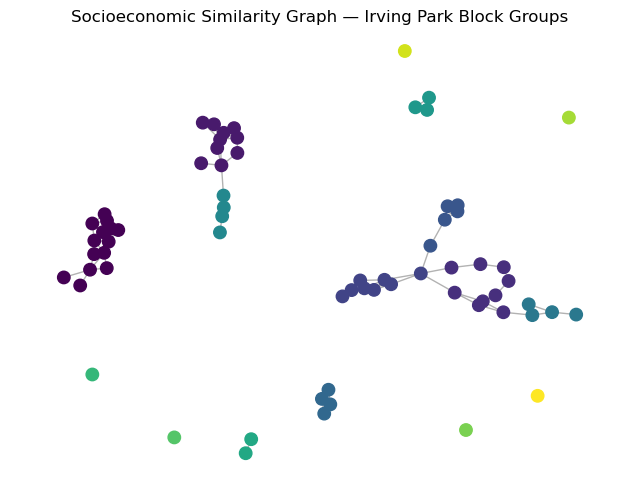

In [24]:
import matplotlib.pyplot as plt

# The graph (network) shows how block groups are connected based on cosine similarity across key socioeconomic variables
# (income, unemployment, vacancy, homeownership, age, race composition). Each node is a block group, and edges link highly similar ones.

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42, weight='weight')
colors = [G.nodes[n]['community'] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap='viridis', node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Socioeconomic Similarity Graph — Irving Park Block Groups")
plt.axis('off')
plt.show()


In [13]:
components = list(nx.connected_components(G))
print(f"{len(components)} connected components")

# Largest component size
largest = max(components, key=len)
print(f"Largest component: {len(largest)} nodes")


12 connected components
Largest component: 26 nodes


In [14]:
import networkx as nx

components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")

# Assign component ID to each node
component_dict = {}
for i, comp in enumerate(components):
    for geoid in comp:
        component_dict[geoid] = i

irving_bg['component'] = irving_bg['GEOID'].map(component_dict)
print(irving_bg['component'].value_counts().head())


Number of connected components: 12
component
1    26
0    14
2    14
6     4
3     3
Name: count, dtype: int64


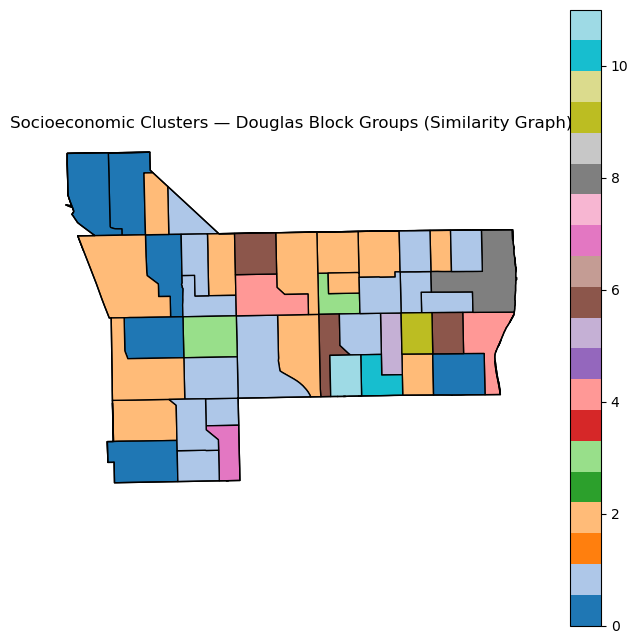

In [15]:
irving_bg['GEOID'] = irving_bg['GEOID'].astype(str)
irving_map = irving_bg.merge(
    irving_bg[['GEOID', 'component']],
    on='GEOID',
    how='left'
)

# The map projects those similarity-based clusters spatially within Irving, showing where socioeconomically similar areas are located.
# Distinct colors indicate separate clusters identified from the similarity network.

fig, ax = plt.subplots(figsize=(8, 8))
irving_map.plot(column='component', cmap='tab20', legend=True, ax=ax, edgecolor='black')
irving.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Socioeconomic Clusters — Irving Block Groups (Similarity Graph)")
ax.axis('off')
plt.show()


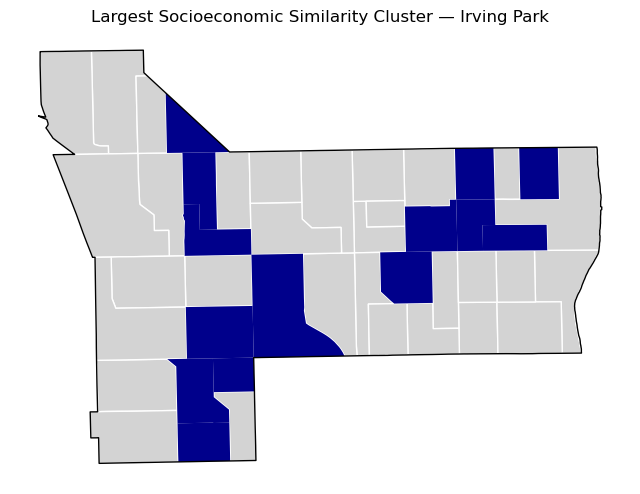

In [25]:
largest = max(components, key=len)
irving_map['in_largest'] = irving_map['GEOID'].isin(largest)

# The map isolates the largest connected cluster, representing Irving’s socioeconomic “core” 
# the contiguous area of block groups that share the most similar economic and demographic conditions.

fig, ax = plt.subplots(figsize=(8, 8))
irving_map.plot(ax=ax, color='lightgrey', edgecolor='white')
irving_map[irving_map['in_largest']].plot(ax=ax, color='darkblue')
irving.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Largest Socioeconomic Similarity Cluster — Irving Park")
ax.axis('off')
plt.show()


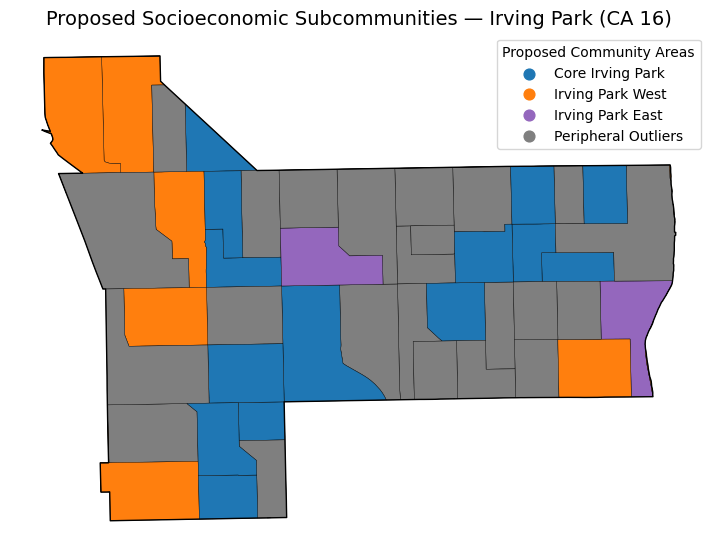

In [30]:
# --- etiquetas para Irving (IDs de 'component' ajusta a los tuyos si quieres) ---
component_to_area = {
    1: "Core Irving Park",
    0: "Irving Park West",
    4: "Irving Park East",
}
irving_map["proposed_area"] = irving_map["component"].map(component_to_area).fillna("Peripheral Outliers")

# --- colores y estilo ---
area_colors = {
    "Core Irving Park": "#1f77b4",       # azul
    "Irving Park West": "#ff7f0e",       # naranja
    "Irving Park East": "#9467bd",       # morado
    "Peripheral Outliers": "#7f7f7f" # gris
}

fig, ax = plt.subplots(figsize=(9, 9))
irving_map.plot(
    ax=ax,
    color=irving_map["proposed_area"].map(area_colors),
    edgecolor="black",
    linewidth=0.3,
)

# usa el borde de Irving (polígono de la CA16) en vez del de Irving
irving.boundary.plot(ax=ax, color="black", linewidth=1)

# leyenda
for label, color in area_colors.items():
    ax.scatter([], [], c=color, label=label, s=60)
ax.legend(title="Proposed Community Areas", loc="upper right", frameon=True)

ax.set_title("Proposed Socioeconomic Subcommunities — Irving Park (CA 16)", fontsize=14)
ax.axis("off")
plt.show()
